# Section A: Concept Application

1. You load an image with cv2.imread() and print its shape, getting (480, 640,3). What do these three values represent?

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
from google.colab import files

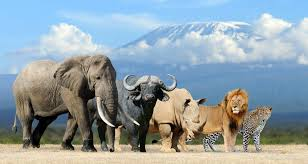

In [ ]:
img = cv2.imread('/content/download (1).jpg')
cv2_imshow(img)

In [ ]:
h, w, c = img.shape
print("Height:", h)
print("Width:", w)
print("Channels:", c)


Height: 164
Width: 308
Channels: 3


2. cv2.imread() loads images in BGR order by default. Why does the BGR vs RGB distinction matter when displaying or passing images to other libraries?

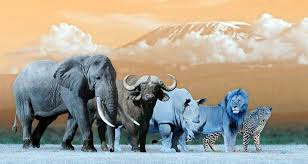

True

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(img_rgb)
cv2.imwrite("rgb_output.jpg", img_rgb)

3. You resize the same image using INTER_LINEAR and INTER_AREA
interpolation. When is INTER_AREA the preferred choice over
INTER_LINEAR

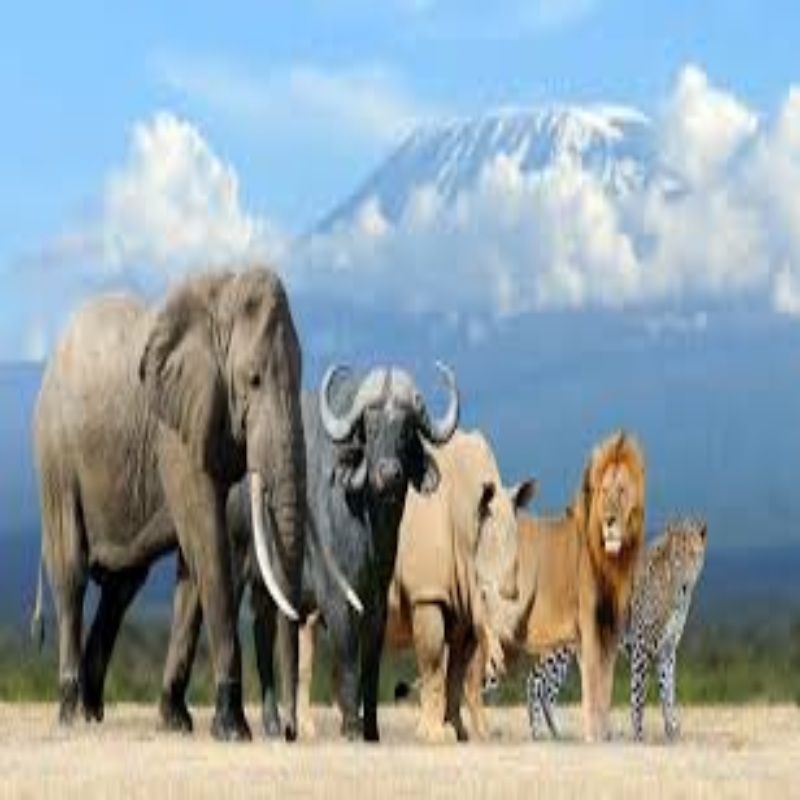

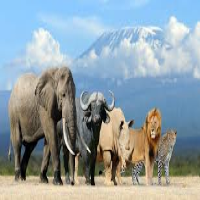

True

In [ ]:
bigger_linear = cv2.resize(img, (800, 800), interpolation=cv2.INTER_LINEAR)
smaller_area = cv2.resize(img, (200, 200), interpolation=cv2.INTER_AREA)
cv2_imshow(bigger_linear)
cv2_imshow(smaller_area)
cv2.imwrite("bigger_linear.jpg", bigger_linear)
cv2.imwrite("smaller_area.jpg", smaller_area)


4. You convert an image from BGR to HSV before processing. What does the HSV colour space represent that BGR does not?

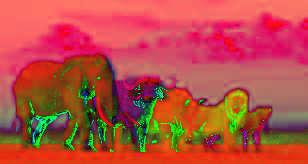

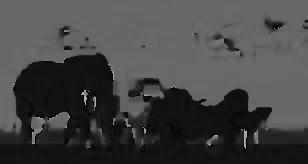

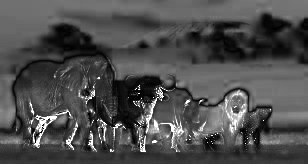

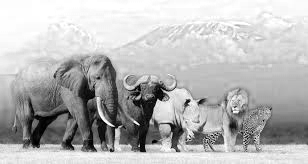

In [ ]:
#Convert BGR → HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
cv2_imshow(img_hsv)
cv2.imwrite("hsv_output.jpg", img_hsv)
h, s, v = cv2.split(img_hsv)
cv2_imshow(h)  # Hue
cv2_imshow(s)  # Saturation
cv2_imshow(v)  # Value

5. You need to extract a specific region from a medical scan. What is the conceptual difference between cropping an image and resizing it?

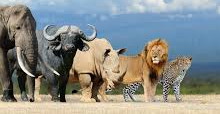

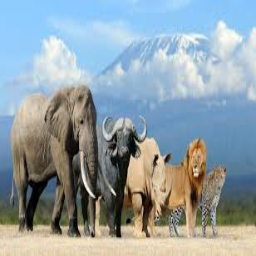

In [ ]:
# Crop region [y1:y2, x1:x2]
crop = img[50:200, 80:300]
resize = cv2.resize(img, (256, 256))
cv2_imshow(crop)
cv2_imshow(resize)

# **Section B: Practical Task**

1. Load multiple JPG and PNG images from the OpenCV samples dataset and validate their $H \times W \times C$ structure

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files
import glob

In [ ]:
uploaded = files.upload()

image_list = []

for name in uploaded.keys():
    img = cv2.imread(name)
    if img is None:
        print(f"❌ Could not load: {name}")
    else:
        print(f"✅ Loaded: {name} | Shape: {img.shape} (H,W,C)")
        image_list.append((name, img))

Saving f.jpg to f.jpg
Saving f2.jpg to f2.jpg
Saving food_i.png to food_i.png
✅ Loaded: f.jpg | Shape: (417, 626, 3) (H,W,C)
✅ Loaded: f2.jpg | Shape: (251, 448, 3) (H,W,C)
✅ Loaded: food_i.png | Shape: (740, 1318, 3) (H,W,C)


2. Perform image resizing using INTER_LINEAR and INTER_CUBIC
interpolation methods and visualize the pixel-level differences.


Processing: f.jpg


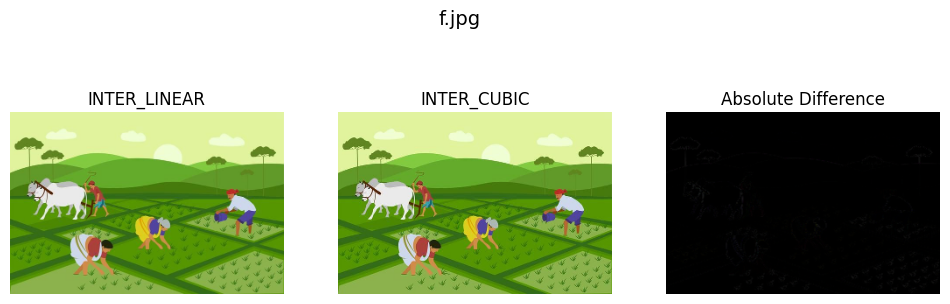


Processing: f2.jpg


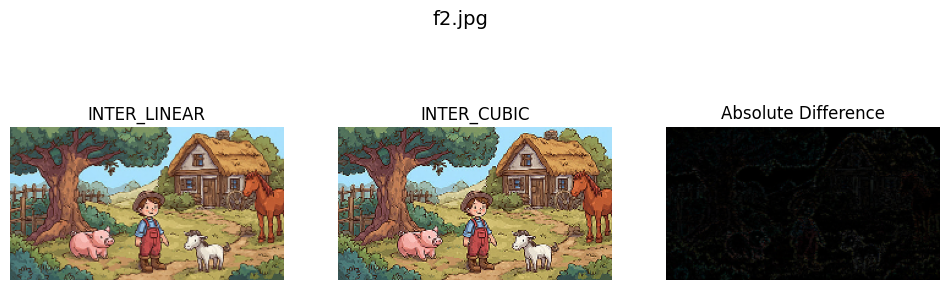


Processing: food_i.png


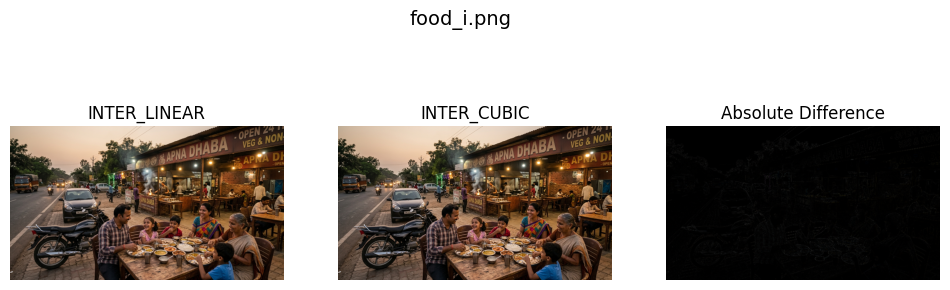

In [ ]:
for name, img in image_list:
    print("\nProcessing:", name)

    h, w = img.shape[:2]

    # Resize
    linear = cv2.resize(img, (w//2, h//2), interpolation=cv2.INTER_LINEAR)
    cubic  = cv2.resize(img, (w//2, h//2), interpolation=cv2.INTER_CUBIC)

    # Compute absolute pixel differences
    diff = cv2.absdiff(linear, cubic)

    # Display
    plt.figure(figsize=(12,4))
    plt.suptitle(name, fontsize=14)

    plt.subplot(1,3,1); plt.title("INTER_LINEAR"); plt.imshow(linear[...,::-1]); plt.axis("off")
    plt.subplot(1,3,2); plt.title("INTER_CUBIC"); plt.imshow(cubic[...,::-1]); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Absolute Difference"); plt.imshow(diff[...,::-1]); plt.axis("off")

    plt.show()

3. Implement a 45-degree and 90-degree rotation using a computed
transformation matrix without cropping the corners.

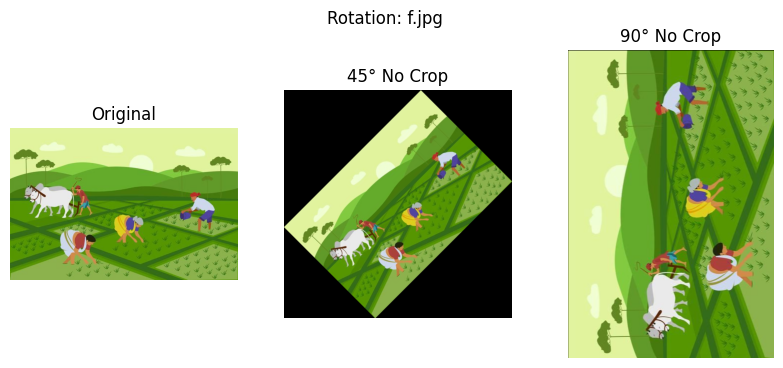

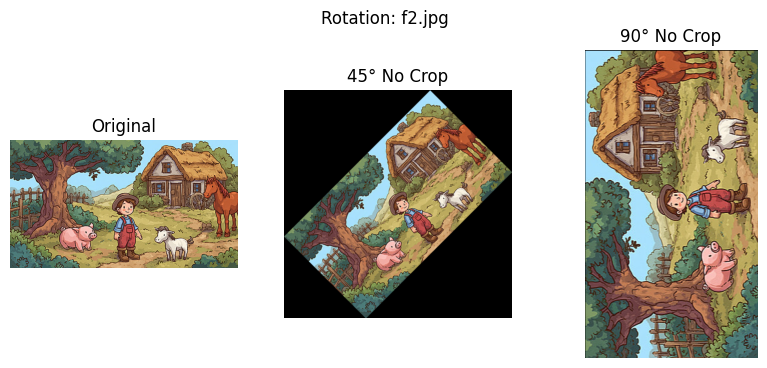

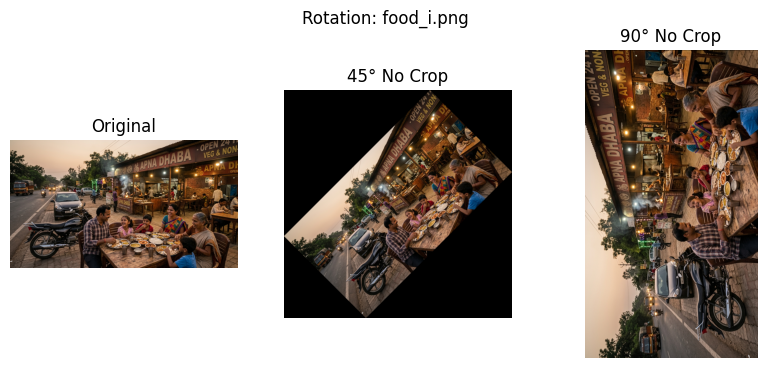

In [ ]:
def rotate_without_crop(img, angle):
    (h, w) = img.shape[:2]
    center = (w//2, h//2)

    #  rotation matrix
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # new bounding dimensions
    cos = np.abs(M[0,0])
    sin = np.abs(M[0,1])

    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    # Adjust matrix to account for translation
    M[0,2] += (new_w/2) - center[0]
    M[1,2] += (new_h/2) - center[1]

    rotated = cv2.warpAffine(img, M, (new_w, new_h))
    return rotated

for name, img in image_list:
    rot_45 = rotate_without_crop(img, 45)
    rot_90 = rotate_without_crop(img, 90)

    plt.figure(figsize=(10,4))
    plt.suptitle(f"Rotation: {name}")

    plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img[...,::-1]); plt.axis("off")
    plt.subplot(1,3,2); plt.title("45° No Crop"); plt.imshow(rot_45[...,::-1]); plt.axis("off")
    plt.subplot(1,3,3); plt.title("90° No Crop"); plt.imshow(rot_90[...,::-1]); plt.axis("off")

    plt.show()

4. Execute a localized region-of-interest (ROI) crop and apply horizontal and vertical flips to the extracted segment.

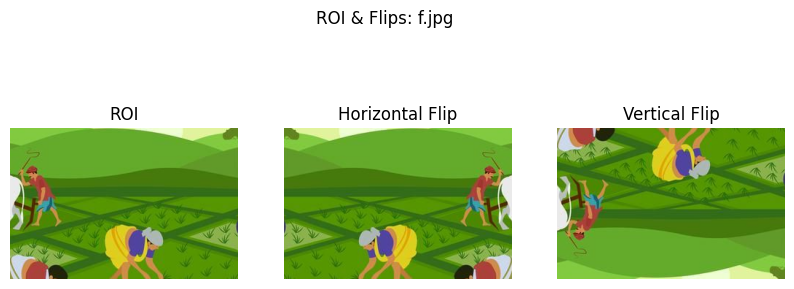

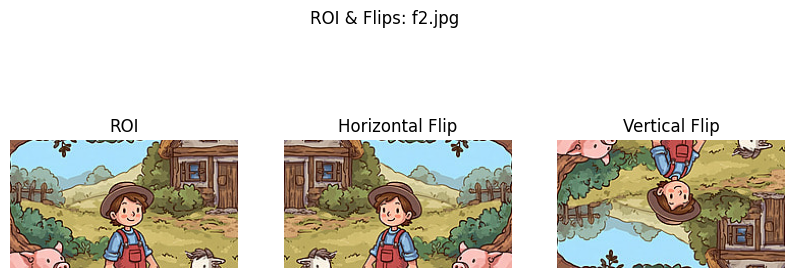

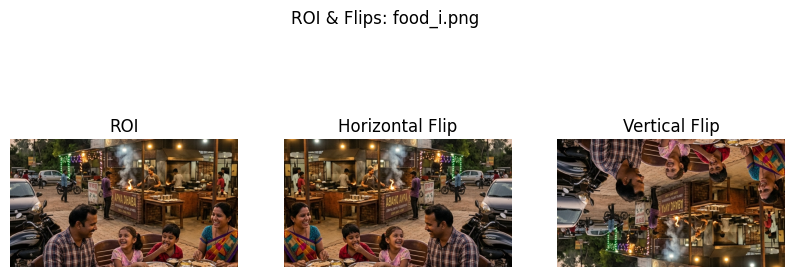

In [ ]:
for name, img in image_list:
    h, w = img.shape[:2]

    # Define ROI center region
    roi = img[h//4 : 3*h//4, w//4 : 3*w//4]

    flip_h = cv2.flip(roi, 1)  # Horizontal flip
    flip_v = cv2.flip(roi, 0)  # Vertical flip

    plt.figure(figsize=(10,4))
    plt.suptitle(f"ROI & Flips: {name}")

    plt.subplot(1,3,1); plt.title("ROI"); plt.imshow(roi[...,::-1]); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Horizontal Flip"); plt.imshow(flip_h[...,::-1]); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Vertical Flip"); plt.imshow(flip_v[...,::-1]); plt.axis("off")

    plt.show()

5. Develop a color-space conversion module to transform BGR source images into Grayscale and HSV formats for feature analysis.

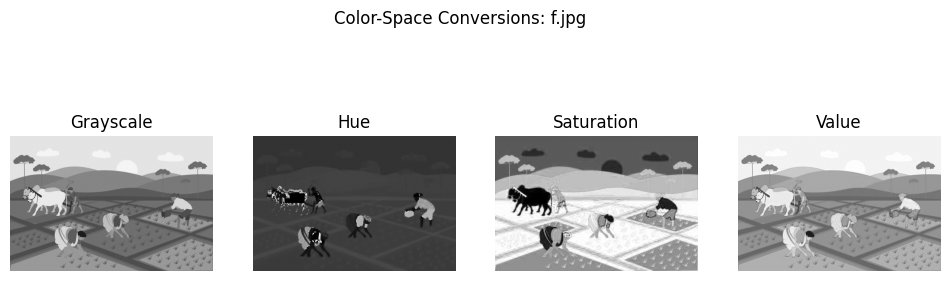

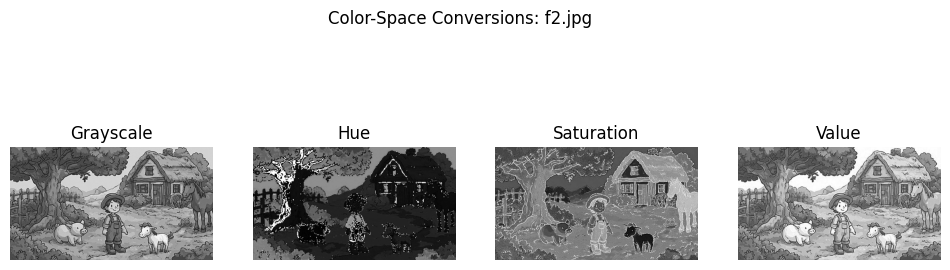

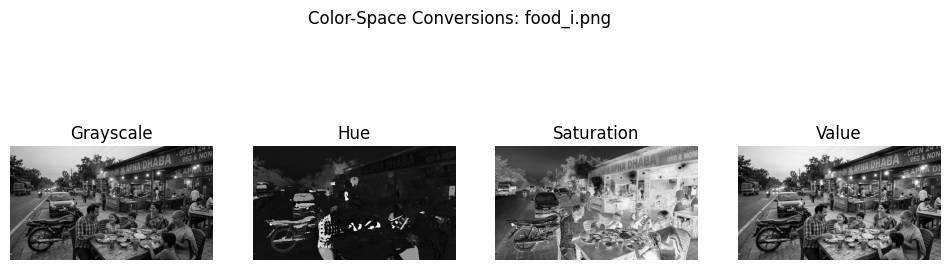

In [ ]:
for name, img in image_list:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv)

    plt.figure(figsize=(12,4))
    plt.suptitle(f"Color-Space Conversions: {name}")

    plt.subplot(1,4,1); plt.title("Grayscale"); plt.imshow(gray, cmap="gray"); plt.axis("off")
    plt.subplot(1,4,2); plt.title("Hue"); plt.imshow(h, cmap="gray"); plt.axis("off")
    plt.subplot(1,4,3); plt.title("Saturation"); plt.imshow(s, cmap="gray"); plt.axis("off")
    plt.subplot(1,4,4); plt.title("Value"); plt.imshow(v, cmap="gray"); plt.axis("off")

    plt.show()

# Section C: Mini Project

# **Title: Automated Medical Scan Normalizer**

Status: NORMAL
Edge Score: 26831


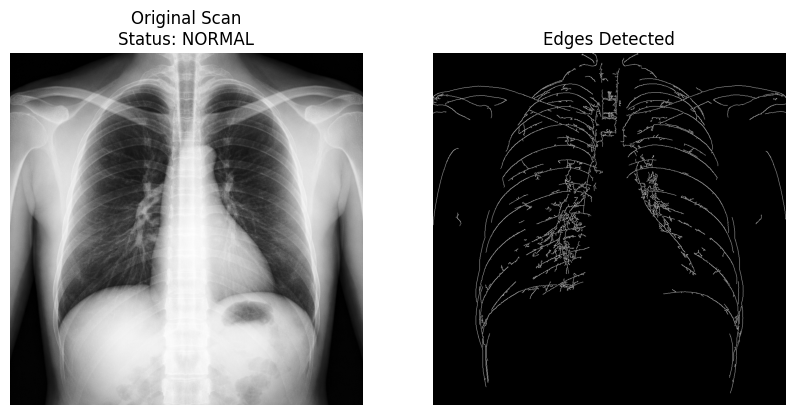

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_abnormal(image_path, threshold=15000):
    # Load grayscale
    img = cv2.imread(image_path, 0)

    if img is None:
        print("Image not found!")
        return

    # Edge detection
    edges = cv2.Canny(img, 50, 150)

    # Count edges
    edge_score = np.sum(edges > 0)

    # Classification logic
    if edge_score < threshold:
        status = "ABNORMAL"
    else:
        status = "NORMAL"

    return img, edges, status, edge_score


# ---------- Run detection ----------
image_path = "/content/x1.png"

orig, edges, status, score = detect_abnormal(image_path)

print("Status:", status)
print("Edge Score:", score)

# ---------- Show result ----------
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title(f"Original Scan\nStatus: {status}")
plt.imshow(orig, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Edges Detected")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.show()